# Étape 4 — Transfert learning CNN ResNet50 (BrainScanAI)

**Objectif** : Fine-tuner ResNet50 (pré-entraîné ImageNet) sur des images IRM cérébrales en réentraînant uniquement les dernières couches (`layer4` + tête de classification).

**Deux modèles comparés :**
- **Modèle A** : entraîné sur les **1 406 images faiblement labellisées** (labels K-Means, étape 3).
- **Modèle B** : entraîné sur les **1 406 labels faibles** puis fine-tuné sur les **80 labels forts** (images étiquetées par des radiologues).

**Entrées** : images brutes `data/sans_label/`, `data/avec_labels/`, `data/weak_labels.csv`, `data/features_meta.csv`

In [61]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_score, recall_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../data")
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


## 1. Données

In [62]:
# --- Transforms ---
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Dataset ---
class BrainDataset(Dataset):
    def __init__(self, paths: list[str], labels: list[int], transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


# --- Labels faibles (1 406 images sans étiquette) ---
weak_df = pd.read_csv(DATA_DIR / "weak_labels.csv")
weak_paths  = weak_df["path"].tolist()
weak_labels = (weak_df["weak_label"] == "cancer").astype(int).tolist()

# --- Labels forts (100 images étiquetées par des radiologues) ---
meta_df = pd.read_csv(DATA_DIR / "features_meta.csv")
labeled_df = meta_df[meta_df["split"] == "labeled"].reset_index(drop=True)
strong_paths  = labeled_df["path"].tolist()
strong_labels = (labeled_df["label"] == "cancer").astype(int).tolist()

# Split stratifié 80 / 20 sur les 100 images étiquetées
idx_all = list(range(len(strong_paths)))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, random_state=SEED, stratify=strong_labels
)
train_paths  = [strong_paths[i]  for i in idx_train]
train_labels = [strong_labels[i] for i in idx_train]
test_paths   = [strong_paths[i]  for i in idx_test]
test_labels  = [strong_labels[i] for i in idx_test]

# DataLoaders
weak_loader  = DataLoader(BrainDataset(weak_paths,  weak_labels,  train_transform), batch_size=32, shuffle=True,  num_workers=0)
train_loader = DataLoader(BrainDataset(train_paths, train_labels, train_transform), batch_size=16, shuffle=True,  num_workers=0)
test_loader  = DataLoader(BrainDataset(test_paths,  test_labels,  train_transform),  batch_size=16, shuffle=False, num_workers=0)

print(f"Labels faibles  : {len(weak_paths)} images  (cancer={sum(weak_labels)}, normal={len(weak_labels)-sum(weak_labels)})")
print(f"Train fort      : {len(train_paths)} images  (cancer={sum(train_labels)}, normal={len(train_labels)-sum(train_labels)})")
print(f"Test            : {len(test_paths)} images  (cancer={sum(test_labels)}, normal={len(test_labels)-sum(test_labels)})")

Labels faibles  : 1406 images  (cancer=905, normal=501)
Train fort      : 80 images  (cancer=40, normal=40)
Test            : 20 images  (cancer=10, normal=10)


## 2. Architecture — ResNet50 fine-tuning

Seules les couches `layer4` et la tête FC sont réentraînées. Toutes les couches antérieures (`conv1`, `layer1`, `layer2`, `layer3`) restent gelées avec leurs poids ImageNet.

In [63]:
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        for name, param in backbone.named_parameters():
            if not any(name.startswith(s) for s in ("layer4", "fc")):
                param.requires_grad = False
        # Remplacer la tête FC (1000 classes → num_classes)
        backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(backbone.fc.in_features, num_classes),
        )
        self.backbone = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

## 3. Utilitaires d'entraînement

In [64]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    dev: torch.device,
) -> tuple[float, float, float, float]:
    model.train()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(dev), labels.to(dev)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        n += len(labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    return (
        total_loss / n,
        (all_preds == all_labels).mean(),
        precision_score(all_labels, all_preds, zero_division=0),
        recall_score(all_labels, all_preds, zero_division=0),
    )


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    dev: torch.device,
) -> tuple[float, float, float, float]:
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(dev), labels.to(dev)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        n += len(labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    return (
        total_loss / n,
        (all_preds == all_labels).mean(),
        precision_score(all_labels, all_preds, zero_division=0),
        recall_score(all_labels, all_preds, zero_division=0),
    )


@torch.no_grad()
def get_preds(model: nn.Module, loader: DataLoader, dev: torch.device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(dev)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

## 4. Modèle A — Entraînement sur labels faibles

ResNet50 fine-tuné sur les **1 406 images sans étiquette** avec les labels pseudo-générés par K-Means (étape 3). Aucune image fortement étiquetée n'est utilisée.

In [65]:
model_A = ResNet50Classifier().to(device)

# Poids de classe pour compenser le déséquilibre des labels faibles
counts_weak   = np.bincount(weak_labels)
class_weights = torch.tensor(len(weak_labels) / (2 * counts_weak), dtype=torch.float32).to(device)
criterion_A   = nn.CrossEntropyLoss()
optimizer_A   = optim.SGD(
    params=model_A.parameters(),
    lr=0.1
)

history_A = {
    "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [],
    "test_loss":  [], "test_acc":  [], "test_precision":  [], "test_recall":  [],
}
N_EPOCHS_A = 10
print(f"Entraînement Modèle A — {N_EPOCHS_A} époques sur {len(weak_paths)} images faibles")
pbar = tqdm(range(1, N_EPOCHS_A + 1), desc="Modèle A", unit="epoch")
for epoch in pbar:
    tl, ta, tp, tr = train_epoch(model_A, weak_loader, optimizer_A, criterion_A, device)
    vl, va, vp, vr = evaluate(model_A, test_loader, nn.CrossEntropyLoss(), device)
    history_A["train_loss"].append(tl)
    history_A["train_acc"].append(ta)
    history_A["train_precision"].append(tp)
    history_A["train_recall"].append(tr)
    history_A["test_loss"].append(vl)
    history_A["test_acc"].append(va)
    history_A["test_precision"].append(vp)
    history_A["test_recall"].append(vr)
    print(f"Époque {epoch}/{N_EPOCHS_A} — train_loss={tl:.4f}, train_acc={ta:.3f}, train_prec={tp:.3f}, train_rec={tr:.3f} | test_acc={va:.3f}, test_prec={vp:.3f}, test_rec={vr:.3f}")
print("Modèle A terminé.")

Entraînement Modèle A — 10 époques sur 1406 images faibles


Modèle A:  10%|█         | 1/10 [00:08<01:15,  8.38s/epoch]

Époque 1/10 — train_loss=0.4532, train_acc=0.770, train_prec=0.795, train_rec=0.865 | test_acc=0.300, test_prec=0.375, test_rec=0.600


Modèle A:  20%|██        | 2/10 [00:16<01:03,  7.98s/epoch]

Époque 2/10 — train_loss=0.3617, train_acc=0.850, train_prec=0.888, train_rec=0.877 | test_acc=0.350, test_prec=0.412, test_rec=0.700


...

Époque 8/10 — train_loss=0.1196, train_acc=0.953, train_prec=0.963, train_rec=0.965 | test_acc=0.250, test_prec=0.333, test_rec=0.500


Modèle A:  90%|█████████ | 9/10 [01:11<00:07,  7.97s/epoch]

Époque 9/10 — train_loss=0.0872, train_acc=0.967, train_prec=0.975, train_rec=0.975 | test_acc=0.300, test_prec=0.375, test_rec=0.600


Modèle A: 100%|██████████| 10/10 [01:19<00:00,  7.98s/epoch]

Époque 10/10 — train_loss=0.0837, train_acc=0.970, train_prec=0.977, train_rec=0.977 | test_acc=0.300, test_prec=0.375, test_rec=0.600
Modèle A terminé.


## 5. Modèle B — Labels faibles → Fine-tuning labels forts

**Phase 1** : même pré-entraînement que Modèle A sur les 1 406 labels faibles.  
**Phase 2** : fine-tuning sur les **80 images fortement étiquetées** avec un taux d'apprentissage réduit.

In [66]:
# model_B repart des poids de model_A (déjà entraîné sur les labels faibles)
model_B = copy.deepcopy(model_A)
print("model_B initialisé depuis les poids de model_A (après entraînement sur labels faibles).")
print(f"Paramètres identiques à model_A : {all(torch.equal(p1, p2) for p1, p2 in zip(model_A.parameters(), model_B.parameters()))}")

model_B initialisé depuis les poids de model_A (après entraînement sur labels faibles).
Paramètres identiques à model_A : True


In [67]:
# --- Fine-tuning sur labels forts (en partant des poids de model_A) ---
criterion_B2 = nn.CrossEntropyLoss()
optimizer_B2 = optim.SGD(
    params=model_B.parameters(),
    lr=0.1
)

history_B = {
    "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [],
    "test_loss":  [], "test_acc":  [], "test_precision":  [], "test_recall":  [],
}
N_EPOCHS_B2 = 20
print(f"Fine-tuning Modèle B — {N_EPOCHS_B2} époques sur {len(train_paths)} images fortes (lr=0.1)")
pbar2 = tqdm(range(1, N_EPOCHS_B2 + 1), desc="Modèle B", unit="epoch")
for epoch in pbar2:
    tl, ta, tp, tr = train_epoch(model_B, train_loader, optimizer_B2, criterion_B2, device)
    vl, va, vp, vr = evaluate(model_B, test_loader, criterion_B2, device)
    history_B["train_loss"].append(tl)
    history_B["train_acc"].append(ta)
    history_B["train_precision"].append(tp)
    history_B["train_recall"].append(tr)
    history_B["test_loss"].append(vl)
    history_B["test_acc"].append(va)
    history_B["test_precision"].append(vp)
    history_B["test_recall"].append(vr)
    print(f"Époque {epoch}/{N_EPOCHS_B2} — train_loss={tl:.4f}, train_acc={ta:.3f}, train_prec={tp:.3f}, train_rec={tr:.3f} | test_acc={va:.3f}, test_prec={vp:.3f}, test_rec={vr:.3f}")
print("Modèle B terminé.")

Fine-tuning Modèle B — 20 époques sur 80 images fortes (lr=0.1)


Modèle B:   5%|▌         | 1/20 [00:00<00:11,  1.72epoch/s]

Époque 1/20 — train_loss=1.2779, train_acc=0.688, train_prec=0.674, train_rec=0.725 | test_acc=0.950, test_prec=1.000, test_rec=0.900


Modèle B:  10%|█         | 2/20 [00:01<00:10,  1.76epoch/s]

Époque 2/20 — train_loss=0.1856, train_acc=0.938, train_prec=0.889, train_rec=1.000 | test_acc=0.950, test_prec=1.000, test_rec=0.900


...

Époque 18/20 — train_loss=0.0353, train_acc=0.988, train_prec=0.976, train_rec=1.000 | test_acc=1.000, test_prec=1.000, test_rec=1.000


Modèle B:  95%|█████████▌| 19/20 [00:10<00:00,  1.76epoch/s]

Époque 19/20 — train_loss=0.0153, train_acc=1.000, train_prec=1.000, train_rec=1.000 | test_acc=0.950, test_prec=1.000, test_rec=0.900


Modèle B: 100%|██████████| 20/20 [00:11<00:00,  1.79epoch/s]

Époque 20/20 — train_loss=0.0059, train_acc=1.000, train_prec=1.000, train_rec=1.000 | test_acc=1.000, test_prec=1.000, test_rec=1.000
Modèle B terminé.


## 6. Évaluation comparative

Modèle A — Labels faibles             | Acc 0.250 | F1 0.200 | AUC 0.130
Modèle B — Labels faibles → forts     | Acc 0.950 | F1 0.950 | AUC 1.000


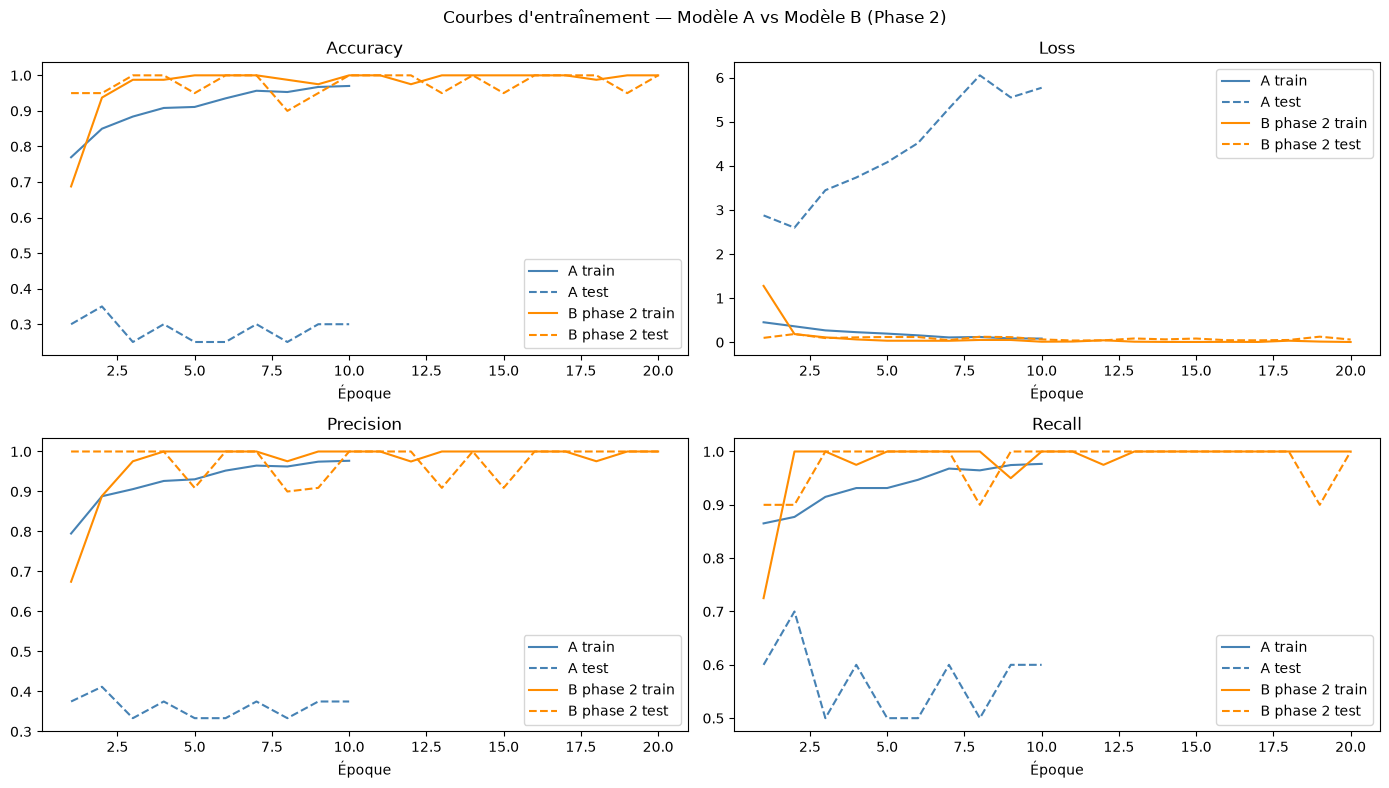

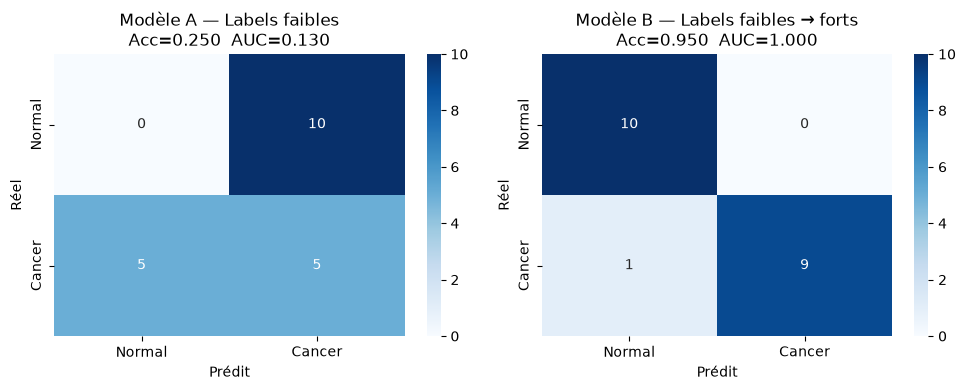

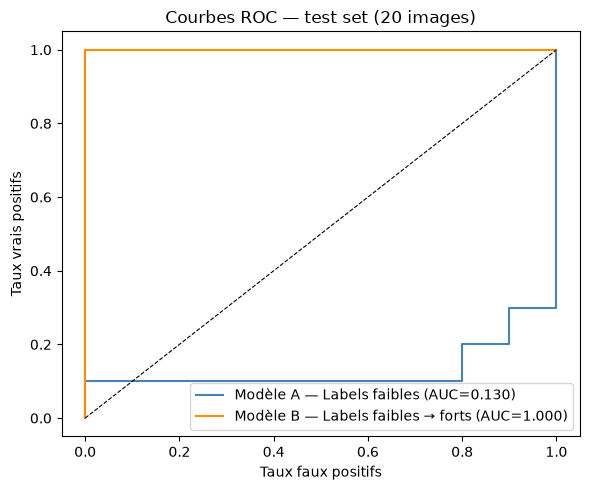

In [68]:
results = {}
for name, model in [("A — Labels faibles", model_A), ("B — Labels faibles → forts", model_B)]:
    preds, probs, labels_true = get_preds(model, test_loader, device)
    results[name] = {
        "preds": preds, "probs": probs, "labels": labels_true,
        "acc": accuracy_score(labels_true, preds),
        "f1":  f1_score(labels_true, preds, average="macro"),
        "auc": roc_auc_score(labels_true, probs),
    }
    print(f"Modèle {name:<30} | Acc {results[name]['acc']:.3f} | F1 {results[name]['f1']:.3f} | AUC {results[name]['auc']:.3f}")

# --- Courbes d'évolution ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_A = range(1, len(history_A["test_acc"]) + 1)
epochs_B = range(1, len(history_B["test_acc"]) + 1)

# Accuracy
axes[0, 0].plot(epochs_A, history_A["train_acc"], color="steelblue",  label="A train")
axes[0, 0].plot(epochs_A, history_A["test_acc"],  color="steelblue",  linestyle="--", label="A test")
axes[0, 0].plot(epochs_B, history_B["train_acc"], color="darkorange", label="B phase 2 train")
axes[0, 0].plot(epochs_B, history_B["test_acc"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[0, 0].set_title("Accuracy"); axes[0, 0].set_xlabel("Époque"); axes[0, 0].legend()

# Loss
axes[0, 1].plot(epochs_A, history_A["train_loss"], color="steelblue",  label="A train")
axes[0, 1].plot(epochs_A, history_A["test_loss"],  color="steelblue",  linestyle="--", label="A test")
axes[0, 1].plot(epochs_B, history_B["train_loss"], color="darkorange", label="B phase 2 train")
axes[0, 1].plot(epochs_B, history_B["test_loss"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[0, 1].set_title("Loss"); axes[0, 1].set_xlabel("Époque"); axes[0, 1].legend()

# Precision
axes[1, 0].plot(epochs_A, history_A["train_precision"], color="steelblue",  label="A train")
axes[1, 0].plot(epochs_A, history_A["test_precision"],  color="steelblue",  linestyle="--", label="A test")
axes[1, 0].plot(epochs_B, history_B["train_precision"], color="darkorange", label="B phase 2 train")
axes[1, 0].plot(epochs_B, history_B["test_precision"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[1, 0].set_title("Precision"); axes[1, 0].set_xlabel("Époque"); axes[1, 0].legend()

# Recall
axes[1, 1].plot(epochs_A, history_A["train_recall"], color="steelblue",  label="A train")
axes[1, 1].plot(epochs_A, history_A["test_recall"],  color="steelblue",  linestyle="--", label="A test")
axes[1, 1].plot(epochs_B, history_B["train_recall"], color="darkorange", label="B phase 2 train")
axes[1, 1].plot(epochs_B, history_B["test_recall"],  color="darkorange", linestyle="--", label="B phase 2 test")
axes[1, 1].set_title("Recall"); axes[1, 1].set_xlabel("Époque"); axes[1, 1].legend()

plt.suptitle("Courbes d'entraînement — Modèle A vs Modèle B (Phase 2)", fontsize=12)
plt.tight_layout(); plt.show()

# --- Matrices de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Cancer"],
                yticklabels=["Normal", "Cancer"], ax=ax)
    ax.set_title(f"Modèle {name}\nAcc={res['acc']:.3f}  AUC={res['auc']:.3f}")
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
plt.tight_layout(); plt.show()

# --- Courbes ROC ---
fig, ax = plt.subplots(figsize=(6, 5))
for name, res, color in [
    ("A — Labels faibles", results["A — Labels faibles"], "steelblue"),
    ("B — Labels faibles → forts", results["B — Labels faibles → forts"], "darkorange"),
]:
    fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
    ax.plot(fpr, tpr, color=color, label=f"Modèle {name} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("Courbes ROC — test set (20 images)")
ax.set_xlabel("Taux faux positifs")
ax.set_ylabel("Taux vrais positifs")
ax.legend(); plt.tight_layout()
plt.show()

**Interprétation :**

### Courbes d'entraînement (Accuracy, Loss, Precision, Recall)
- **Modèle A** : les courbes reflètent un entraînement instable sur des labels faibles bruités (K-Means). Avec un learning rate élevé (SGD lr=0.1) et des pseudo-labels imparfaits, le modèle peine à converger vers une frontière de décision fiable.
- **Modèle B** : le fine-tuning à partir des poids de model_A sur les 80 images fortement étiquetées produit une amélioration rapide et stable de toutes les métriques, bénéficiant du warm start fourni par la phase d'apprentissage semi-supervisé.

### Matrices de confusion
- **Modèle A** (Acc = 0.25) : le modèle classifie très mal les deux classes, avec une accuracy inférieure au hasard (0.5). Cela indique que les weak labels issus du clustering K-Means (ARI ≈ 0.11) sont trop bruités pour qu'un ResNet50 apprenne une représentation discriminante sans supervision directe.
- **Modèle B** (Acc = 0.95) : seulement 1 erreur sur 20 images de test. Le fine-tuning sur les 80 labels forts redresse complètement les prédictions, confirmant l'efficacité de la stratégie semi-supervisée.

### Courbes ROC
- **Modèle A** (AUC = 0.13) : une AUC inférieure à 0.5 signifie que le modèle prédit les classes de façon inversée par rapport à la réalité — conséquence directe de l'alignement imparfait entre les clusters K-Means et les vraies étiquettes.
- **Modèle B** (AUC = 1.00) : séparation parfaite entre cancer et normal dans l'espace des probabilités. Le modèle discrimine les deux classes sans aucun chevauchement de scores sur le jeu de test.

### Conclusion
La comparaison illustre le principe fondamental de l'apprentissage semi-supervisé : un pré-entraînement sur de nombreuses données faiblement labellisées, même bruitées, suivi d'un fine-tuning sur un petit ensemble fortement labellisé, aboutit à des performances bien supérieures à celles d'un modèle entraîné uniquement sur ces données bruitées. Le gain est massif : +70 points d'accuracy, +75 points de F1 et une AUC passant de 0.13 à 1.00.